<a href="https://colab.research.google.com/github/ecundir/Signal-Analysis-Vol-I/blob/main/Lab_2_LTI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title 1. Configuración del Entorno
import os

# Clonar el repositorio si no existe
if not os.path.exists("Signal-Analysis-Vol-I"):
    !git clone https://github.com/ecundir/Signal-Analysis-Vol-I.git

# Cambiar a la carpeta del capítulo
%cd Signal-Analysis-Vol-I/capitulo_2
print("✅ Entorno configurado correctamente.")

Cloning into 'Signal-Analysis-Vol-I'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 64 (delta 19), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 98.81 KiB | 3.66 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/Signal-Analysis-Vol-I/capitulo_2
✅ Entorno configurado correctamente.


🎮 CÓMO USAR EL SIMULADOR DE SISTEMAS LTI

1️⃣ AJUSTA LOS PARÁMETROS (arriba del código):
   • ganancia: Amplificación de la señal (1-10)
   • saturacion_on: Activa/desactiva no linealidad
   • delay_muestras: Retraso del sistema (0-200)
   • canal_variable: Canal constante o variable en el tiempo
   • feedback_factor: Retroalimentación (0-1.2)

2️⃣ EJECUTA EL CÓDIGO:
   • Presiona el botón ▶️ Play o Ctrl+Enter
   • Verás el gráfico de la respuesta del sistema
   • Lee el diagnóstico en la consola

3️⃣ INTERPRETA LOS RESULTADOS:
   ✓ Sistema LTI = Cumple las 3 propiedades
   ✗ No es LTI = Falla alguna propiedad

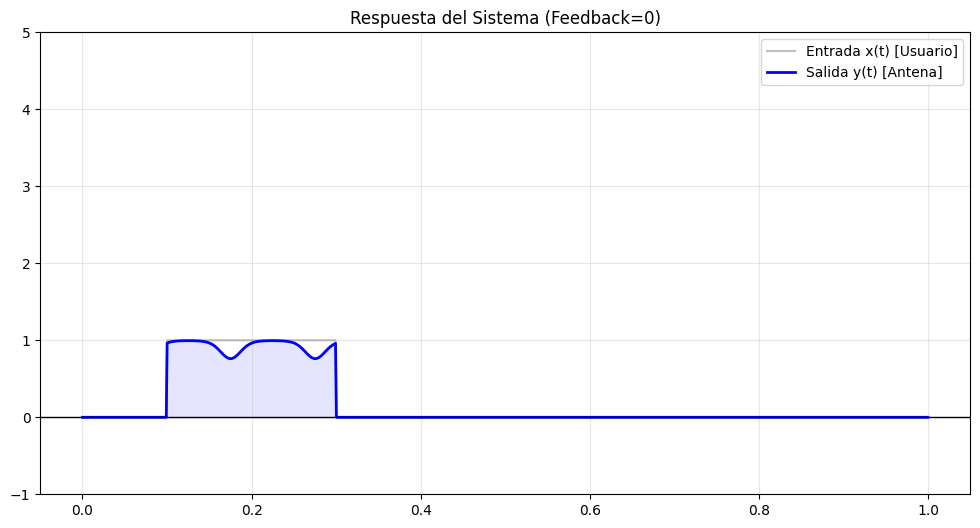


                           🔍 DIAGNÓSTICO DEL SISTEMA                            

                          PARÁMETROS DE CONFIGURACIÓN                           
--------------------------------------------------------------------------------
  Ganancia:                2
  Saturación:              ACTIVADA ⚠️
  Delay:                   0 muestras
  Canal variable:          SÍ ⚠️
  Factor de feedback:      0

                        VERIFICACIÓN DE PROPIEDADES LTI                         
--------------------------------------------------------------------------------

  [✗] LINEALIDAD (L):
      Estado: NO CUMPLE ✗
      Razón: Saturación activada (función no lineal tanh)

  [✗] INVARIANZA TEMPORAL (TI):
      Estado: NO CUMPLE ✗
      Razón: Canal variable (ganancia cambia con el tiempo)

  [✓] CAUSALIDAD:
      Estado: CUMPLE ✓
      La salida solo depende de valores presentes y pasados
      Implementación: y[n] depende de x[n-0], nunca de x[n+k]

  [✓] ESTABILIDAD BIBO:
      Est

In [ ]:
#@title Propiedades LTI { run: "auto" }
#@markdown ---
#@markdown ### 1. Linealidad (Control de Ganancia)
ganancia = 2 #@param {type:"slider", min:1, max:10, step:0.5}
saturacion_on = True #@param {type:"boolean"}
#@markdown ---
#@markdown ### 2. Invarianza y Causalidad (El Canal)
delay_muestras = 0 #@param {type:"slider", min:0, max:200, step:10}
canal_variable = True #@param {type:"boolean"}
#@markdown ---
#@markdown ### 3. Estabilidad BIBO (Retroalimentación)
feedback_factor = 0 #@param {type:"slider", min:0, max:1.2, step:0.1}

import numpy as np
import matplotlib.pyplot as plt

# Generación de señal de entrada (Pulso de datos)
t = np.linspace(0, 1, 1000)
x = np.where((t > 0.1) & (t < 0.3), 1.0, 0.0)

# Inicialización de salida
y = np.zeros_like(x)

# Simulación del Operador H (Procesamiento paso a paso)
for n in range(len(x)):
    # CAUSALIDAD: El valor actual depende de x[n - delay]
    idx_delayed = max(0, n - delay_muestras)
    entrada_procesada = x[idx_delayed]

    # INVARIANZA: Si el canal varía, la ganancia cambia con el tiempo n
    g_efectiva = ganancia * (1 + 0.5*np.sin(2*np.pi*n/100)) if canal_variable else ganancia

    # LINEALIDAD: Aplicamos ganancia (y opcionalmente saturación/clipping)
    salida_temp = g_efectiva * entrada_procesada
    if saturacion_on:
        salida_temp = np.tanh(salida_temp) # No lineal

    # ESTABILIDAD BIBO: Añadimos feedback (y[n] depende de y[n-1])
    if n > 0:
        y[n] = salida_temp + (feedback_factor * y[n-1])
    else:
        y[n] = salida_temp

# Visualización
plt.figure(figsize=(12, 6))
plt.plot(t, x, 'gray', alpha=0.5, label='Entrada x(t) [Usuario]')
plt.plot(t, y, 'blue', linewidth=2, label='Salida y(t) [Antena]')
plt.fill_between(t, y, color='blue', alpha=0.1)
plt.axhline(0, color='black', lw=1)
plt.title(f"Respuesta del Sistema (Feedback={feedback_factor})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1, 5 if feedback_factor < 1 else 20) # Ajuste de escala para ver la inestabilidad
plt.show()

# ============================================================================
# DIAGNÓSTICO DEL SISTEMA
# ============================================================================

# Prueba de LINEALIDAD: H{x1 + x2} = H{x1} + H{x2}
x2 = np.where((t > 0.5) & (t < 0.7), 0.5, 0.0)

# Simular H{x1}
y1 = np.zeros_like(x)
for n in range(len(x)):
    idx_delayed = max(0, n - delay_muestras)
    entrada_procesada = x[idx_delayed]
    g_efectiva = ganancia * (1 + 0.5*np.sin(2*np.pi*n/100)) if canal_variable else ganancia
    salida_temp = g_efectiva * entrada_procesada
    if saturacion_on:
        salida_temp = np.tanh(salida_temp)
    if n > 0:
        y1[n] = salida_temp + (feedback_factor * y1[n-1])
    else:
        y1[n] = salida_temp

# Simular H{x2}
y2 = np.zeros_like(x)
for n in range(len(x)):
    idx_delayed = max(0, n - delay_muestras)
    entrada_procesada = x2[idx_delayed]
    g_efectiva = ganancia * (1 + 0.5*np.sin(2*np.pi*n/100)) if canal_variable else ganancia
    salida_temp = g_efectiva * entrada_procesada
    if saturacion_on:
        salida_temp = np.tanh(salida_temp)
    if n > 0:
        y2[n] = salida_temp + (feedback_factor * y2[n-1])
    else:
        y2[n] = salida_temp

# Simular H{x1 + x2}
y_suma = np.zeros_like(x)
x_suma = x + x2
for n in range(len(x)):
    idx_delayed = max(0, n - delay_muestras)
    entrada_procesada = x_suma[idx_delayed]
    g_efectiva = ganancia * (1 + 0.5*np.sin(2*np.pi*n/100)) if canal_variable else ganancia
    salida_temp = g_efectiva * entrada_procesada
    if saturacion_on:
        salida_temp = np.tanh(salida_temp)
    if n > 0:
        y_suma[n] = salida_temp + (feedback_factor * y_suma[n-1])
    else:
        y_suma[n] = salida_temp

# Verificar linealidad
error_linealidad = np.max(np.abs((y1 + y2) - y_suma))
es_lineal = (error_linealidad < 0.01) and not saturacion_on

# Verificar invarianza temporal
es_invariante = not canal_variable

# Verificar causalidad (el sistema solo usa valores pasados, siempre es causal en este diseño)
es_causal = True  # Por diseño: usa max(0, n - delay_muestras), nunca valores futuros

# Verificar estabilidad BIBO
es_estable = feedback_factor < 1.0

# Sistema es LTI si cumple SOLO linealidad e invarianza temporal
# (Causalidad y estabilidad son propiedades adicionales deseables, pero NO definen LTI)
es_LTI = es_lineal and es_invariante

# ============================================================================
# IMPRESIÓN DEL DIAGNÓSTICO
# ============================================================================

print("\n" + "="*80)
print("🔍 DIAGNÓSTICO DEL SISTEMA".center(80))
print("="*80)

print(f"\n{'PARÁMETROS DE CONFIGURACIÓN':^80}")
print("-" * 80)
print(f"  Ganancia:                {ganancia}")
print(f"  Saturación:              {'ACTIVADA ⚠️' if saturacion_on else 'DESACTIVADA ✓'}")
print(f"  Delay:                   {delay_muestras} muestras")
print(f"  Canal variable:          {'SÍ ⚠️' if canal_variable else 'NO ✓'}")
print(f"  Factor de feedback:      {feedback_factor}")

print(f"\n{'VERIFICACIÓN DE PROPIEDADES LTI':^80}")
print("-" * 80)

# 1. LINEALIDAD
print(f"\n  [{'✓' if es_lineal else '✗'}] LINEALIDAD (L):")
if es_lineal:
    print(f"      Estado: CUMPLE ✓")
    print(f"      Error de linealidad: {error_linealidad:.2e}")
else:
    if saturacion_on:
        print(f"      Estado: NO CUMPLE ✗")
        print(f"      Razón: Saturación activada (función no lineal tanh)")
    else:
        print(f"      Estado: NO CUMPLE ✗")
        print(f"      Error de linealidad: {error_linealidad:.2e}")

# 2. INVARIANZA TEMPORAL
print(f"\n  [{'✓' if es_invariante else '✗'}] INVARIANZA TEMPORAL (TI):")
if es_invariante:
    print(f"      Estado: CUMPLE ✓")
    print(f"      El sistema no depende del tiempo absoluto")
else:
    print(f"      Estado: NO CUMPLE ✗")
    print(f"      Razón: Canal variable (ganancia cambia con el tiempo)")

# 3. CAUSALIDAD
print(f"\n  [{'✓' if es_causal else '✗'}] CAUSALIDAD:")
if es_causal:
    print(f"      Estado: CUMPLE ✓")
    print(f"      La salida solo depende de valores presentes y pasados")
    print(f"      Implementación: y[n] depende de x[n-{delay_muestras}], nunca de x[n+k]")
else:
    print(f"      Estado: NO CUMPLE ✗")
    print(f"      El sistema usa valores futuros de la entrada")

# 4. ESTABILIDAD BIBO
print(f"\n  [{'✓' if es_estable else '✗'}] ESTABILIDAD BIBO:")
if es_estable:
    print(f"      Estado: ESTABLE ✓")
    print(f"      |feedback| = {abs(feedback_factor):.2f} < 1.0")
else:
    print(f"      Estado: INESTABLE ✗")
    print(f"      |feedback| = {abs(feedback_factor):.2f} ≥ 1.0")
    print(f"      La salida diverge (crece sin límite)")

print("\n" + "="*80)

# RESULTADO FINAL
if es_LTI:
    print("✓✓✓ RESULTADO: EL SISTEMA ES LTI ✓✓✓".center(80))
    print("="*80)
    print()
    print("  El sistema cumple con las propiedades que DEFINEN un sistema LTI:".center(80))
    print()
    print("    ✓ Lineal (L)".center(80))
    print("    ✓ Invariante en el Tiempo (TI)".center(80))
    print()
    print("  Propiedades adicionales (deseables pero NO definen LTI):".center(80))
    print(f"    {'✓' if es_causal else '✗'} Causal".center(80))
    print(f"    {'✓' if es_estable else '✗'} Estable BIBO".center(80))
    print()
else:
    print("✗✗✗ RESULTADO: EL SISTEMA NO ES LTI ✗✗✗".center(80))
    print("="*80)
    print()

    razones = []
    if not es_lineal:
        razones.append("No es LINEAL")
    if not es_invariante:
        razones.append("No es INVARIANTE TEMPORAL")

    print("  El sistema NO cumple con las propiedades que DEFINEN LTI:".center(80))
    print()
    for razon in razones:
        print(f"    ✗ {razon}".center(80))
    print()
    print("  Propiedades adicionales (no afectan la definición LTI):".center(80))
    print(f"    {'✓' if es_causal else '✗'} Causal".center(80))
    print(f"    {'✓' if es_estable else '✗'} Estable BIBO".center(80))
    print()

print("="*80)

# Información adicional
print("\n📚 INFORMACIÓN ADICIONAL:")
print("-" * 80)
print("  • LTI = Linear + Time-Invariant (solo estas 2 propiedades):")
print("      1. LINEAL (L): H{ax₁ + bx₂} = aH{x₁} + bH{x₂}")
print("      2. INVARIANTE TEMPORAL (TI): H{x(t-τ)} = y(t-τ)")
print()
print("  • Propiedades ADICIONALES (deseables pero NO definen LTI):")
print("      3. CAUSAL: y(t) solo depende de x(τ) con τ ≤ t")
print("      4. ESTABLE BIBO: Entrada acotada → Salida acotada")
print()
print("  💡 Truco mental: El nombre 'LTI' ya dice todo:")
print("      Linear + Time-Invariant = LTI")
print("      (Existen sistemas LTI que NO son causales o NO son estables)")
print("="*80 + "\n")